# 02 - Feature Engineering

Turns the URLs of the subset into a numerical feature table, checks its quality and analyzes how well each feature separates the classes. Final output: `data/processed/features.csv`.

> The first cell sets the working directory to the project root, so the paths always work.

In [1]:
import os
while not os.path.isdir('data') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: C:\Users\Matteo\Desktop\Cybersecurity\2_Sem\Machine Learning\Progetto\Git.py_project


## Load the data and apply the features

In [2]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from features import extract_features

df = pd.read_csv('data/subset/malicious_urls_subset.csv')
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (15000, 2)


,url,type
0,www.webring.com/hub?ring=roff,phishing
1,content.yudu.com/Library/A1n8cr/MontrealJewish...,benign
2,http://www.thereefrestaurant.com/wp-content/pl...,malware
3,nytimes.com/1997/03/28/classified/paid-notice-...,benign
4,wsaz.com/jeopardy,benign


In [3]:
feat = df['url'].apply(extract_features).apply(pd.Series)
data = pd.concat([feat, df['type']], axis=1)
print('Numerical table:', data.shape)
data.head()

Numerical table: (15000, 26)


,url_length,hostname_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,num_digits,num_special_chars,...,has_port,is_shortened,has_suspicious_tld,has_executable_extension,suspicious_word_count,brand_name_count,entropy_url,entropy_hostname,digit_ratio,type
0,29.0,15.0,4.0,9.0,2.0,0.0,0.0,1.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.935,3.240,0.000,phishing
1,69.0,16.0,53.0,0.0,3.0,0.0,0.0,5.0,4.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.576,3.250,0.058,benign
2,99.0,25.0,57.0,9.0,6.0,3.0,0.0,7.0,4.0,19.0,...,0.0,1.0,0.0,0.0,0.0,0.0,4.619,3.593,0.040,malware
3,71.0,11.0,60.0,0.0,2.0,4.0,0.0,5.0,8.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.519,3.278,0.113,benign
4,17.0,8.0,9.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.852,3.000,0.000,benign


## Quality check
The first two lists must be EMPTY (no NaN, no infinities). The third shows useless features (always the same value).

In [4]:
nan = data.isna().sum()
print('NaN per column:\n', nan[nan > 0])
num = data.select_dtypes('number')
inf = np.isinf(num).sum()
print('\nColumns with infinities:\n', inf[inf > 0])
print('\nConstant (useless) features:', [c for c in num.columns if data[c].nunique() == 1])

NaN per column:
 Series([], dtype: int64)

Columns with infinities:
 Series([], dtype: int64)

Constant (useless) features: []


## Check that the parsing fix works
For URLs without `http://`, `hostname_length` must be > 0 (min > 0).

In [5]:
mask = ~df['url'].str.startswith(('http://', 'https://'))
print('URLs without scheme:', int(mask.sum()))
print(data.loc[mask, 'hostname_length'].describe())

URLs without scheme: 10855
count    10855.000000
mean        17.412621
std         12.605058
min          4.000000
25%         12.000000
50%         15.000000
75%         20.000000
max        234.000000
Name: hostname_length, dtype: float64


## Discriminative power of the features (the core of this step)
Look for features whose boxes sit at different heights across the 4 classes.

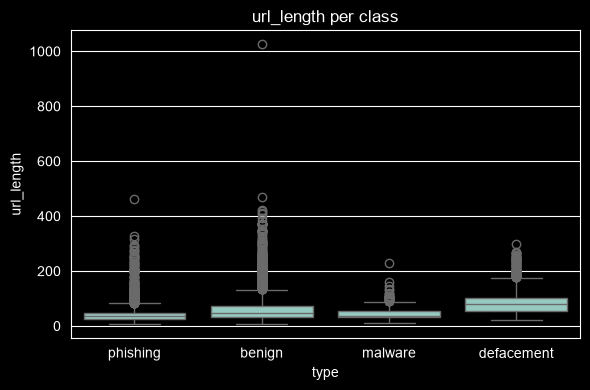

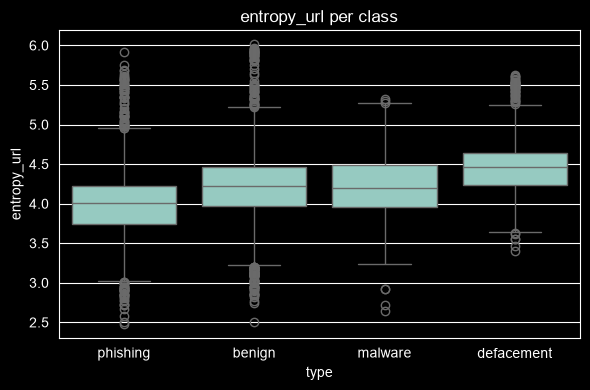

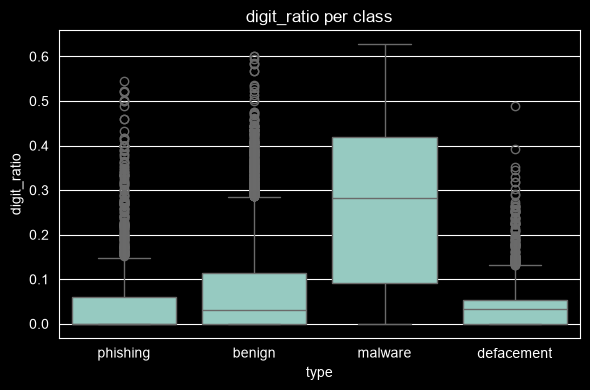

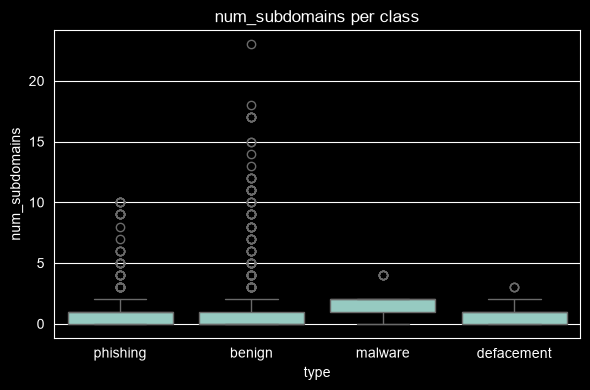

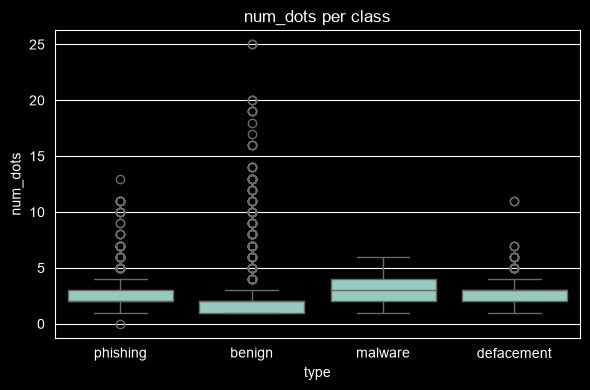

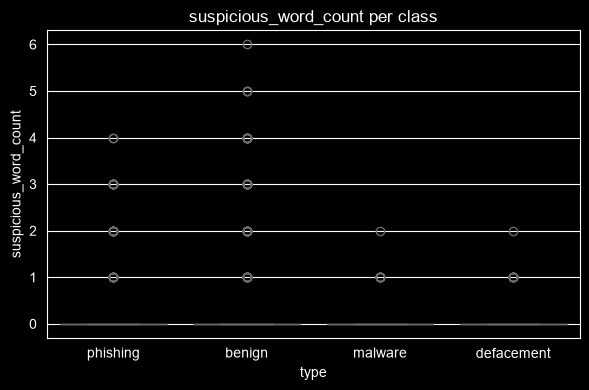

In [6]:
key_feats = ['url_length', 'entropy_url', 'digit_ratio', 'num_subdomains', 'num_dots', 'suspicious_word_count']
os.makedirs('figures', exist_ok=True)
for f in key_feats:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x='type', y=f)
    plt.title(f'{f} per class')
    plt.tight_layout()
    plt.savefig(f'figures/box_{f}.png', dpi=120)
    plt.show()

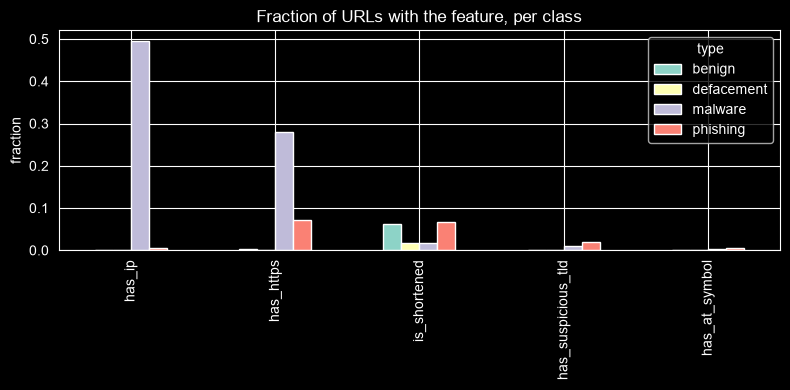

In [7]:
bin_feats = ['has_ip', 'has_https', 'is_shortened', 'has_suspicious_tld', 'has_at_symbol']
data.groupby('type')[bin_feats].mean().T.plot(kind='bar', figsize=(8, 4))
plt.title('Fraction of URLs with the feature, per class')
plt.ylabel('fraction')
plt.tight_layout()
plt.savefig('figures/bin_features.png', dpi=120)
plt.show()

## Redundant features (correlation)

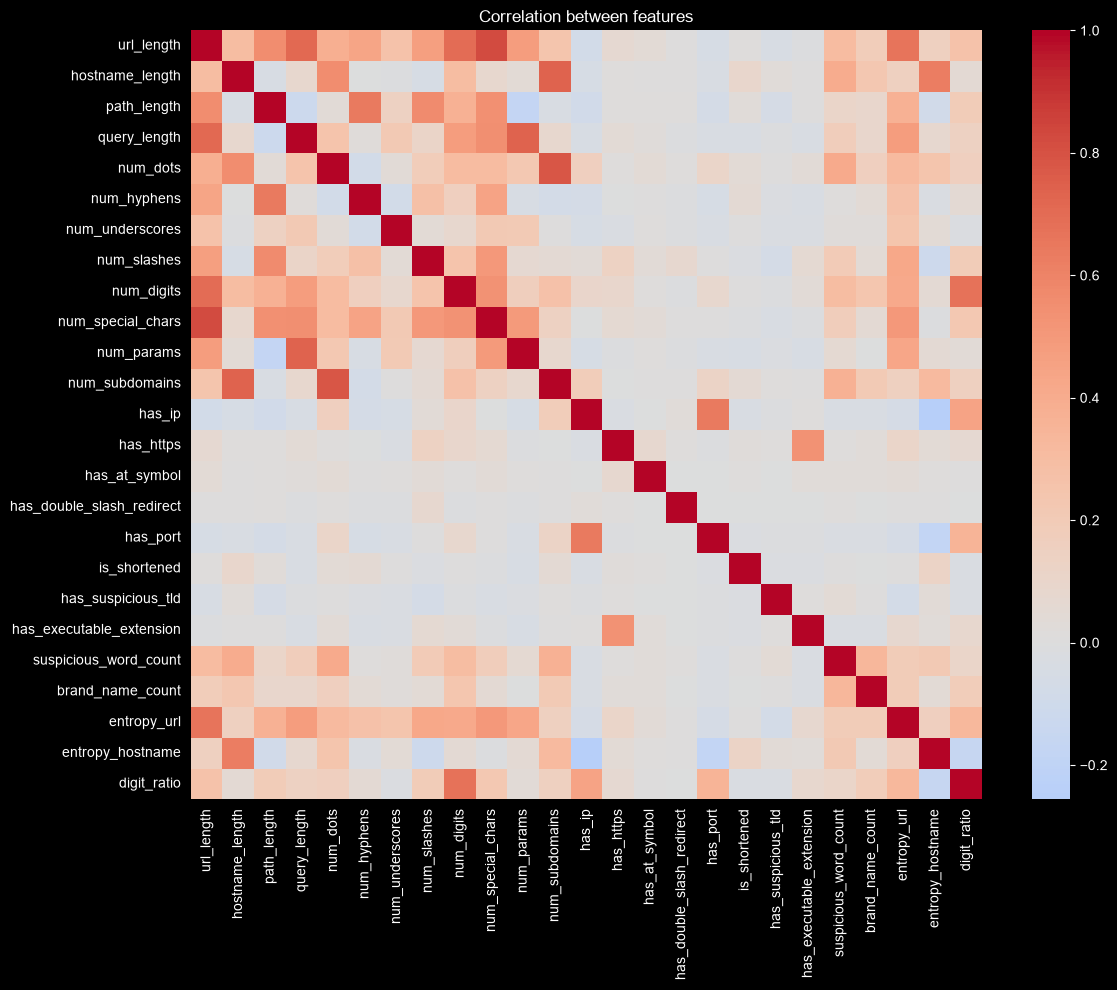

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(num.corr(), cmap='coolwarm', center=0)
plt.title('Correlation between features')
plt.tight_layout()
plt.savefig('figures/corr_heatmap.png', dpi=120)
plt.show()

## Save the processed dataset

In [9]:
os.makedirs('data/processed', exist_ok=True)
data.to_csv('data/processed/features.csv', index=False)
print('Saved data/processed/features.csv with shape:', data.shape)

Saved data/processed/features.csv with shape: (15000, 26)


## Conclusions - Feature Engineering

**Features that separate the classes well.** The two most discriminative features relate to malware: `has_ip` (~50% of malware URLs point to a raw IP, near-zero elsewhere) and `digit_ratio` (median ~0.28 for malware vs ~0.02-0.03 for the others). `entropy_url` separates gradually (phishing lowest ~3.9, defacement highest ~4.4). `url_length` is a moderate signal with strong overlap. `num_dots` is slightly lower for benign. `has_https` gives a secondary signal for malware and phishing.

**Weak features in their current form.** `suspicious_word_count` is almost always 0; `has_at_symbol`, `has_suspicious_tld`, `is_shortened` and `num_subdomains` are weak.

**Redundant features.** A strongly inter-correlated block of size/complexity features (`url_length`, `path_length`, `query_length`, `num_dots`, `num_digits`, `num_special_chars`, `num_slashes`, `num_params`, `entropy_url`). The binary/host features are weakly correlated and carry independent information.

**Decisions.** Keep all features for now. Note (1) redundancy suggests dimensionality reduction / l1 could help; (2) word/TLD features underperform on this dataset - an honest result to report.